# 20 - Dynamic resilience - peak hours vs off-peak

Our earlier resilience calculations used one graph containing every scheduled connection in the feed. That is useful for the overall structure, but it does not represent the service available at a particular hour. In notebook 19 we built separate graphs for each time window. Here we use those graphs to ask:

> **Does criticality depend on the time of day?** Are the same stations critical during the morning peak and at night, and is the network more fragile when service is thin?

We run two experiments.

1. **Rank stability across windows.** We recompute degree, weighted degree, and sampled betweenness inside each window, then compare the station rankings with Spearman correlation and top-50 overlap. We also repeat betweenness on the same graph with another seed, which gives us a noise baseline for judging whether a cross-window difference is larger than sampling variation.
2. **Targeted versus random removal in each window.** We repeat the progressive-removal test within every graph. The damage measure is `|LCC| / (N - k)`, the fraction of surviving stations still in the largest component. We use removal fractions instead of fixed counts so graphs of different sizes can be compared on the same scale.

The goal is to see whether the same stations matter throughout the day and whether a thinner schedule makes the network easier to fragment.

## Input

* `outputs/nb/19_*/tables/window_summary.csv` - one row per time window
  (`window, start_hour, end_hour, trips, nodes, directed_edges, avg_degree, largest_component_share`).
* `outputs/nb/19_*/graph_<window>.pkl` - the undirected graph for each window (preferred), **or**
  `outputs/nb/19_*/tables/edges_<window>.csv` (`from_stop, to_stop, trip_frequency`) if the pickle is missing.
* `outputs/nb/02_graph_construction/tables/nodes.csv` - station names, coordinates, and regions, used only to label the results.

**Required inputs:** We need `02_graph_construction` for station labels and notebook 19 for the per-window graphs.
We do not read the raw 816 MB `stop_times.txt` again because notebook 19 has already converted it into window-level graph files.

## Output

We write all results under `outputs/nb/20_dynamic_resilience/`:

* `tables/dynamic_resilience.csv` - `window, strategy, removed, largest_component_share_surviving`
  (the contract table; one row per window x strategy x removal level).
* `tables/peak_vs_offpeak_centrality.csv` - `stop_id, stop_name, window, degree, weighted_degree,
  approx_betweenness, rank_in_window` (the contract table; one row per station in each window).
* `dynamic_summary.json` - the main summary values, the chosen peak / off-peak windows, and every constant that was used.
* Supplementary tables: `window_graph_summary.csv`, `window_rank_agreement.csv`, `rank_movers.csv`,
  `vanished_at_offpeak.csv`, `dynamic_resilience_detail.csv`, `fragility_summary.csv`,
  `betweenness_noise_floor.csv`.
* Figures: `damage_curves_by_window.png`, `damage_curves_grid.png`, `rank_agreement_heatmap.png`,
  `top_rank_movers.png`, `fragility_summary.png`.

No files from the input stages are changed.

## 1. Environment setup

We start with the same environment setup used throughout the project. `_ensure(...)` installs only missing packages, and `find_repo_root()` finds our local data folder or clones the repository in Colab. The cell defines `REPO`, `DATA`, and `OUT`, which all later file paths use.

In [ ]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

## 2. Libraries, stage folders, and tunable constants

We keep the settings that control runtime and sampling accuracy in one cell. The expensive parts are betweenness estimation and the repeated connected-component calculations:

| Constant | Meaning | Cost |
|---|---|---|
| `BETWEENNESS_SAMPLES = 250` | number of pivots for sampled betweenness, **per window** | about 250 BFS sweeps per window; 20-60 seconds on a 25k-node window graph |
| `RUN_NOISE_FLOOR = True` | one extra betweenness run on the peak window with a second seed | +one betweenness run |
| `REMOVAL_FRACTIONS` / `EXTRA_FRACTIONS` | the removal grid, expressed as a **fraction of each window's stations** | one connected-components pass per point |
| `RANDOM_TRIALS = 3` | seeded repeats averaged for the random baseline | triples the baseline cost |
| `ATTACK_STRATEGIES` | which targeted attack orders to simulate | one sweep each |

With `W` windows, the simulation makes about `W x (len(ATTACK_STRATEGIES) + RANDOM_TRIALS) x 24` connected-component evaluations. For four windows, four strategies, and three random trials, that is roughly 670 passes plus one sampled-betweenness run per window. We use subgraph views rather than full copies so memory stays manageable.

`RANK_METRIC` selects the score behind `rank_in_window`. We use approximate betweenness by default because we want structural importance, but we compare all three measures across windows instead of relying on that one choice.

`PEAK_WINDOW_OVERRIDE` and `OFFPEAK_WINDOW_OVERRIDE` let us force the direct comparison. When they are `None`, we choose the pair from the available window names and sizes later.

In [2]:
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn')

import json, pickle, random, re, time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.0)

# ---------------- stage folders ----------------
STAGE = OUT / '20_dynamic_resilience'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# ---------------- tunable constants: all runtime cost lives here ----------------
BETWEENNESS_SAMPLES = 250      # pivots for sampled betweenness, per window
BETWEENNESS_SEED = 42          # seed of the main sample
BETWEENNESS_SEED_B = 7         # second seed, used only for the noise-floor check
RUN_NOISE_FLOOR = True         # False -> skip the second betweenness run
REUSE_CENTRALITY_CACHE = True   # validated cache skips the five main betweenness runs

RANK_METRIC = 'approx_betweenness'   # metric behind the contract column rank_in_window
AGREEMENT_METRICS = ['degree', 'weighted_degree', 'approx_betweenness']
TOP_OVERLAP_N = 50             # the "top-50 overlap" of the agreement table
MOVER_POOL = 2000              # a station must be top-2000 in at least one window to count as a mover
TOP_MOVERS = 20                # rows in the mover figure (per direction)

# removal grid, as a SHARE of each window's own station count (windows differ in size)
REMOVAL_FRACTIONS = [round(x, 4) for x in np.linspace(0.0, 0.10, 21)]
EXTRA_FRACTIONS = [0.0005, 0.001, 0.0025]    # small-k anchors so the early curve is resolved
RANDOM_TRIALS = 3              # seeded trials averaged for the random baseline
SEED = 42
ATTACK_STRATEGIES = ['degree', 'weighted degree', 'betweenness', 'articulation points']

PEAK_WINDOW_OVERRIDE = None    # e.g. 'am_peak'  -> forces the peak side of the head-to-head
OFFPEAK_WINDOW_OVERRIDE = None # e.g. 'night'    -> forces the off-peak side

FIG_DPI = 150

assert RANK_METRIC in AGREEMENT_METRICS, 'RANK_METRIC must be one of AGREEMENT_METRICS'

# numpy 2 renamed trapz -> trapezoid; support both.
_trapz = getattr(np, 'trapezoid', None) or np.trapz

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('stage folder :', STAGE)
print('networkx', nx.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

stage folder : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience
networkx 3.4.2 | pandas 2.3.3 | numpy 1.26.4


## 3. Handling Hebrew labels

The rank-mover plot uses Hebrew station names. We select fonts that include Hebrew glyphs and keep `fix_he()` consistent with this Matplotlib build, which already handles the text direction. The cell also removes a stale text patch if one exists, so rerunning the setup does not reverse labels twice.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Locating the input stages

We locate stage folders by their two-digit prefix, which keeps the loader independent of the descriptive folder suffix. If a required stage is missing, the helper stops with a specific error before any analysis begins.

Two stages are required:

* **19** supplies the per-window graphs and `window_summary.csv`.
* **02** supplies `nodes.csv` for station names, coordinates, and regions.

In [4]:
def find_stage(prefix, must_run):
    """Return the outputs/nb stage folder whose name starts with `prefix` (e.g. '19')."""
    hits = sorted(p for p in OUT.glob(prefix + '*') if p.is_dir()) if OUT.exists() else []
    if not hits:
        raise FileNotFoundError(
            'No stage folder starting with "' + prefix + '" under ' + str(OUT) + ' - '
            'run notebook ' + must_run + ' first.')
    return hits[0]


def find_file(root, *patterns):
    """First file under `root` matching one of the glob patterns, searched recursively."""
    if root is None or not Path(root).exists():
        return None
    for pat in patterns:
        hits = sorted(Path(root).rglob(pat))
        if hits:
            return hits[0]
    return None


STAGE19 = find_stage('19', '19 (time-windowed graph construction)')
STAGE02 = find_stage('02', '02_graph_construction')
print('window stage :', STAGE19)
print('nodes stage  :', STAGE02)

window stage : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\19_time_of_day_graphs
nodes stage  : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction


## 5. Discovering the time windows

We discover the available `graph_<window>.pkl` and `edges_<window>.csv` files instead of copying the window names into this notebook. We normalize the file and summary labels so forms such as `AM Peak`, `am_peak`, and `am-peak` match. Missing graph files are listed and skipped; a graph without a matching summary row can still be analyzed, although it will not have start and end hours.

We prefer the pickle because it contains the graph as constructed in notebook 19. The edge CSV is a fallback in case a pickle cannot be loaded under the current NetworkX version.

In [5]:
def _slug(s):
    return re.sub(r'[^a-z0-9]+', '_', str(s).strip().lower()).strip('_')


# --- files written by notebook 19 -----------------------------------------
pkl_by_slug, csv_by_slug = {}, {}
for p in sorted(STAGE19.rglob('graph_*.pkl')):
    pkl_by_slug.setdefault(_slug(p.stem[len('graph_'):]), p)
for p in sorted(STAGE19.rglob('edges_*.csv')):
    csv_by_slug.setdefault(_slug(p.stem[len('edges_'):]), p)

# --- window_summary.csv (hour boundaries, trip counts) --------------------
ws_path = find_file(STAGE19, 'window_summary.csv')
window_summary = None
if ws_path is not None:
    window_summary = pd.read_csv(ws_path, encoding='utf-8-sig')
    window_summary['_slug'] = window_summary['window'].map(_slug)
    print('window_summary.csv <-', ws_path, '(' + str(len(window_summary)), 'windows )')
else:
    print('WARNING: window_summary.csv not found under', STAGE19,
          '- window labels will be taken from the file names and hour boundaries will be blank.')

# --- assemble the window list ---------------------------------------------
order = (list(window_summary['_slug']) if window_summary is not None
         else sorted(set(pkl_by_slug) | set(csv_by_slug)))
seen, WINDOWS, missing = set(), [], []
for slug in order:
    if slug in seen:
        continue
    seen.add(slug)
    pkl, csv = pkl_by_slug.get(slug), csv_by_slug.get(slug)
    if pkl is None and csv is None:
        missing.append(slug)
        continue
    label = slug
    row = {}
    if window_summary is not None:
        hit = window_summary[window_summary['_slug'] == slug]
        if len(hit):
            row = hit.iloc[0].to_dict()
            label = str(row['window'])
    WINDOWS.append({'window': label, 'slug': slug, 'pkl': pkl, 'csv': csv,
                    'start_hour': row.get('start_hour'), 'end_hour': row.get('end_hour'),
                    'trips': row.get('trips')})
# graph files with no summary row
for slug in sorted(set(pkl_by_slug) | set(csv_by_slug)):
    if slug not in seen:
        WINDOWS.append({'window': slug, 'slug': slug, 'pkl': pkl_by_slug.get(slug),
                        'csv': csv_by_slug.get(slug), 'start_hour': None,
                        'end_hour': None, 'trips': None})

if not WINDOWS:
    raise FileNotFoundError(
        'No per-window graphs found under ' + str(STAGE19) + '. Expected graph_<window>.pkl or '
        'tables/edges_<window>.csv - run notebook 19 (time-windowed graph construction) first.')
if missing:
    print('WARNING: windows listed in window_summary.csv with no graph file (skipped):', missing)

print()
print('windows to analyse (' + str(len(WINDOWS)) + '):')
for w in WINDOWS:
    src = 'pickle' if w['pkl'] is not None else 'edges csv'
    print('  ' + str(w['window']).ljust(18), '| source:', src.ljust(9),
          '| hours:', w['start_hour'], '->', w['end_hour'])

window_summary.csv <- C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\19_time_of_day_graphs\tables\window_summary.csv (5 windows )

windows to analyse (5):
  morning_peak       | source: pickle    | hours: 6 -> 9
  midday             | source: pickle    | hours: 9 -> 15
  afternoon_peak     | source: pickle    | hours: 15 -> 19
  evening            | source: pickle    | hours: 19 -> 23
  night              | source: pickle    | hours: 23 -> 6


## 6. Loading the per-window graphs

For each window we load the graph, convert it to an undirected projection if necessary, merge frequencies from opposite directions, remove self-loops, and convert every node ID to a string. Normalizing the IDs is important because pickle and CSV inputs can otherwise use different types and produce empty intersections during comparison.

We attach the attributes from `nodes.csv` to the nodes present in each graph and write their sizes to `window_graph_summary.csv`. The change in active station count is already a useful result because it measures how much scheduled coverage disappears between windows.

In [6]:
def to_undirected_sum(D):
    """Collapse a directed graph into an undirected one, summing both directions' weights."""
    U = nx.Graph()
    U.add_nodes_from(D.nodes(data=True))
    for u, v, data in D.edges(data=True):
        if u == v:
            continue
        w = float(data.get('weight', data.get('trip_frequency', 1)))
        if U.has_edge(u, v):
            U[u][v]['weight'] += w
        else:
            U.add_edge(u, v, weight=w)
    return U


def graph_from_edges_csv(path):
    """Rebuild the undirected, trip-frequency weighted window graph from edges_<window>.csv."""
    e = pd.read_csv(path, dtype={'from_stop': str, 'to_stop': str}, encoding='utf-8-sig')
    wcol = next((c for c in ('trip_frequency', 'weight', 'trips', 'count') if c in e.columns), None)
    G = nx.Graph()
    ws = (pd.to_numeric(e[wcol], errors='coerce').fillna(1.0).tolist() if wcol else [1.0] * len(e))
    for a, b, w in zip(e['from_stop'].astype(str), e['to_stop'].astype(str), ws):
        if a == b:
            continue
        if G.has_edge(a, b):
            G[a][b]['weight'] += float(w)
        else:
            G.add_edge(a, b, weight=float(w))
    return G


def load_window_graph(rec):
    """Load one window as an undirected, str-labelled, self-loop-free graph."""
    G = None
    # Prefer the portable CSV. A pickle can be readable but stale after a partial rerun.
    if rec['csv'] is not None:
        G = graph_from_edges_csv(rec['csv'])
    elif rec['pkl'] is not None:
        try:
            with open(rec['pkl'], 'rb') as fh:
                G = pickle.load(fh)
        except Exception as exc:
            raise RuntimeError('could not load window graph ' + str(rec['pkl']) + ': ' + str(exc)) from exc
    if G is None:
        raise FileNotFoundError('no usable graph file for window ' + str(rec['window']))
    if G.is_directed():
        G = to_undirected_sum(G)
    else:
        G = nx.Graph(G)
    G = nx.relabel_nodes(G, {n: str(n) for n in G.nodes()}, copy=True)
    G.remove_edges_from(list(nx.selfloop_edges(G)))
    for _, _, d in G.edges(data=True):
        d['weight'] = float(d.get('weight', d.get('trip_frequency', 1)))
    return G


# --- station labels from stage 02 -----------------------------------------
nodes_path = find_file(STAGE02, 'nodes.csv')
if nodes_path is None:
    raise FileNotFoundError('nodes.csv not found under ' + str(STAGE02) +
                            ' - run notebook 02_graph_construction first.')
nodes_df = pd.read_csv(nodes_path, dtype={'stop_id': str}, encoding='utf-8-sig')
NODE_ATTR = nodes_df.set_index(nodes_df['stop_id'].astype(str))[
    ['stop_name', 'lat', 'lon', 'region']].to_dict('index')
print('station labels:', len(NODE_ATTR), 'stops  <-', nodes_path)
print()

# --- load every window -----------------------------------------------------
GRAPHS, rows = {}, []
for rec in WINDOWS:
    t0 = time.time()
    G = load_window_graph(rec)
    for n in G.nodes():
        a = NODE_ATTR.get(n)
        if a:
            G.nodes[n].update(a)
    GRAPHS[rec['window']] = G
    comps = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
    n, m = G.number_of_nodes(), G.number_of_edges()
    rows.append({'window': rec['window'], 'start_hour': rec['start_hour'], 'end_hour': rec['end_hour'],
                 'trips_reported_by_nb19': rec['trips'], 'nodes': n, 'undirected_edges': m,
                 'avg_degree': round(2 * m / n, 3) if n else 0.0,
                 'components': len(comps),
                 'largest_component': comps[0] if comps else 0,
                 'largest_component_share': round(comps[0] / n, 4) if n else 0.0,
                 'total_edge_weight': float(sum(d['weight'] for _, _, d in G.edges(data=True)))})
    print('  ' + str(rec['window']).ljust(18), format(n, '>7,'), 'nodes ',
          format(m, '>7,'), 'edges  (' + str(round(time.time() - t0, 1)) + 's)')

window_graph_summary = pd.DataFrame(rows)
empty = window_graph_summary[window_graph_summary['nodes'] < 3]['window'].tolist()
if empty:
    print()
    print('WARNING: dropping windows with fewer than 3 stations (nothing to simulate):', empty)
    window_graph_summary = window_graph_summary[window_graph_summary['nodes'] >= 3].reset_index(drop=True)
window_graph_summary.to_csv(TABLES / 'window_graph_summary.csv', index=False, encoding='utf-8-sig')
WINDOW_NAMES = list(window_graph_summary['window'])
if not WINDOW_NAMES:
    raise ValueError('every window graph from notebook 19 is empty - nothing to analyse.')
print()
print(window_graph_summary.drop(columns=['trips_reported_by_nb19']).to_string(index=False))

station labels: 30463 stops  <- C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\nodes.csv



  morning_peak        30,072 nodes   46,766 edges  (0.4s)


  midday              30,195 nodes   48,015 edges  (0.5s)


  afternoon_peak      30,057 nodes   46,995 edges  (0.5s)


  evening             29,359 nodes   44,774 edges  (0.5s)


  night               25,967 nodes   38,069 edges  (0.4s)

        window  start_hour  end_hour  nodes  undirected_edges  avg_degree  components  largest_component  largest_component_share  total_edge_weight
  morning_peak           6         9  30072             46766       3.110          10              29852                   0.9927          2622779.0
        midday           9        15  30195             48015       3.180          13              29968                   0.9925          5533609.0
afternoon_peak          15        19  30057             46995       3.127          12              29833                   0.9925          3264471.0
       evening          19        23  29359             44774       3.050           8              29145                   0.9927          2656064.0
         night          23         6  25967             38069       2.932          23              25664                   0.9883          1213850.0


## 7. Choosing the peak and off-peak windows

We run the main calculations on every window, but the mover and vanished-station tables need one peak and one off-peak graph. We choose them with the following rule:

1. explicit `PEAK_WINDOW_OVERRIDE` / `OFFPEAK_WINDOW_OVERRIDE`;
2. keyword match on the name (`peak`, `morning`, `rush`, `am` for the peak side; `night`, `late`, `off`, `evening` for the off-peak side);
3. failing both, the **largest** window by station count is taken as the peak and the **smallest** as the off-peak.

We print the selected pair and the rule that selected it, then save both in `dynamic_summary.json`. That makes it clear which graphs the direct comparison uses.

In [7]:
PEAK_KEYWORDS = ['am_peak', 'morning_peak', 'peak_am', 'rush', 'peak', 'morning', 'am']
OFFPEAK_KEYWORDS = ['night', 'late', 'off_peak', 'offpeak', 'off', 'evening', 'early']


def _match_keyword(names, keywords):
    for kw in keywords:
        for nm in names:
            if kw in _slug(nm):
                return nm, 'name keyword "' + kw + '"'
    return None, None


def choose_windows(summary):
    names = list(summary['window'])
    by_size = summary.sort_values('nodes', ascending=False)['window'].tolist()

    if PEAK_WINDOW_OVERRIDE in names:
        peak, why_p = PEAK_WINDOW_OVERRIDE, 'PEAK_WINDOW_OVERRIDE'
    else:
        peak, why_p = _match_keyword(names, PEAK_KEYWORDS)
        if peak is None:
            peak, why_p = by_size[0], 'largest window by station count'

    off_names = [n for n in names if n != peak]
    if OFFPEAK_WINDOW_OVERRIDE in off_names:
        off, why_o = OFFPEAK_WINDOW_OVERRIDE, 'OFFPEAK_WINDOW_OVERRIDE'
    else:
        off, why_o = _match_keyword(off_names, OFFPEAK_KEYWORDS)
        if off is None:
            off = next((n for n in reversed(by_size) if n != peak), None)
            why_o = 'smallest window by station count'
    return peak, why_p, off, why_o


if len(WINDOW_NAMES) < 2:
    PEAK_WINDOW, OFFPEAK_WINDOW = WINDOW_NAMES[0], None
    WHY_PEAK = WHY_OFFPEAK = 'only one window available'
    print('WARNING: notebook 19 produced a single window (' + str(PEAK_WINDOW) + '). '
          'The cross-window comparisons below will be skipped; only the per-window '
          'resilience simulation is meaningful.')
else:
    PEAK_WINDOW, WHY_PEAK, OFFPEAK_WINDOW, WHY_OFFPEAK = choose_windows(window_graph_summary)

print('peak window     :', PEAK_WINDOW, ' (' + str(WHY_PEAK) + ')')
print('off-peak window :', OFFPEAK_WINDOW, ' (' + str(WHY_OFFPEAK) + ')')

peak window     : morning_peak  (name keyword "morning_peak")
off-peak window : night  (name keyword "night")


## 8. Centrality within each window

For each window we compute three measures on that window's graph:

* **degree** - how many distinct neighboring stations can be reached directly *in this window*;
* **weighted degree (strength)** - the same, weighted by the number of trips using each segment, that is, how much service actually passes through the station at these hours;
* **approximate betweenness** - the sampled share of shortest paths that pass through a station. Exact betweenness is too slow at this size, so we use `BETWEENNESS_SAMPLES` pivots on the largest connected component and assign zero to nodes outside it. We measure the seed-to-seed variation in section 10.

`rank_in_window` is based on `RANK_METRIC`, with rank 1 as the most central station. We break ties by weighted degree, degree, and then `stop_id`. This prevents the many zero-betweenness ties from creating artificial rank movement between otherwise identical runs.

We save the main station-window ranking table to `peak_vs_offpeak_centrality.csv` and a wider detail table with coordinates, region, and separate ranks for each measure. The detail table supports the comparisons and plots below.

In [8]:
def window_metrics(name, G, seed=BETWEENNESS_SEED):
    """degree / weighted degree / sampled betweenness + a deterministic rank, for one window."""
    if G.number_of_nodes() == 0:
        return pd.DataFrame(columns=['stop_id', 'window', 'degree', 'weighted_degree',
                                     'approx_betweenness', 'rank_in_window'])
    deg = dict(G.degree())
    wdeg = dict(G.degree(weight='weight'))
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    Gc = G.subgraph(comps[0])
    k = min(BETWEENNESS_SAMPLES, Gc.number_of_nodes())
    print('  starting ' + str(name) + ': sampled betweenness on ' +
          format(Gc.number_of_nodes(), ',') + ' nodes with k=' + str(k) + ' ...',
          flush=True)
    t0 = time.time()
    btw = nx.betweenness_centrality(Gc, k=k, seed=seed, normalized=True)
    took = time.time() - t0

    df = pd.DataFrame({'stop_id': [str(n) for n in G.nodes()]})
    df['window'] = name
    df['degree'] = df['stop_id'].map(deg).astype(float)
    df['weighted_degree'] = df['stop_id'].map(wdeg).astype(float)
    df['approx_betweenness'] = df['stop_id'].map(btw).fillna(0.0).astype(float)
    df['in_largest_component'] = df['stop_id'].isin(set(map(str, Gc.nodes())))
    df['stop_name'] = df['stop_id'].map(
        lambda s: str((NODE_ATTR.get(s) or {}).get('stop_name', '') or ''))
    df['lat'] = df['stop_id'].map(lambda s: (NODE_ATTR.get(s) or {}).get('lat'))
    df['lon'] = df['stop_id'].map(lambda s: (NODE_ATTR.get(s) or {}).get('lon'))
    df['region'] = df['stop_id'].map(
        lambda s: str((NODE_ATTR.get(s) or {}).get('region', '') or ''))

    # deterministic ranks: value desc, ties broken by weighted degree -> degree -> id
    for metric in AGREEMENT_METRICS:
        s = df.sort_values([metric, 'weighted_degree', 'degree', 'stop_id'],
                           ascending=[False, False, False, True])
        df.loc[s.index, 'rank_' + metric] = np.arange(1, len(s) + 1)
    df['rank_in_window'] = df['rank_' + RANK_METRIC].astype(int)
    df = df.sort_values('rank_in_window').reset_index(drop=True)
    print('  ' + str(name).ljust(18), 'betweenness on', format(Gc.number_of_nodes(), ','),
          'nodes with k=' + str(k), '->', str(round(took, 1)) + 's')
    return df


CONTRACT_COLS = ['stop_id', 'stop_name', 'window', 'degree', 'weighted_degree',
                 'approx_betweenness', 'rank_in_window']
CENTRALITY_TABLE = TABLES / 'window_centrality_detail.csv'
CENTRALITY_META = STAGE / 'window_centrality_cache.json'
source_records = {}
for rec in WINDOWS:
    source = rec['csv'] if rec['csv'] is not None else rec['pkl']
    source_records[str(rec['window'])] = {
        'path': str(source.relative_to(REPO)),
        'size': source.stat().st_size,
        'mtime_ns': source.stat().st_mtime_ns,
    }
centrality_contract = {
    'version': 1,
    'betweenness_samples': BETWEENNESS_SAMPLES,
    'betweenness_seed': BETWEENNESS_SEED,
    'rank_metric': RANK_METRIC,
    'agreement_metrics': AGREEMENT_METRICS,
    'sources': source_records,
}

centrality_cache_hit = False
if REUSE_CENTRALITY_CACHE and CENTRALITY_TABLE.exists() and CENTRALITY_META.exists():
    try:
        with open(CENTRALITY_META, encoding='utf-8') as handle:
            saved_contract = json.load(handle)
        if saved_contract != centrality_contract:
            raise ValueError('source files or centrality parameters changed')
        cached_metrics = pd.read_csv(CENTRALITY_TABLE, dtype={'stop_id': str},
                                     encoding='utf-8-sig')
        required = set(CONTRACT_COLS + ['in_largest_component', 'rank_' + RANK_METRIC])
        if not required.issubset(cached_metrics.columns):
            raise ValueError('cached centrality table has an invalid schema')
        if set(cached_metrics['window'].astype(str)) != set(map(str, WINDOW_NAMES)):
            raise ValueError('cached centrality table has different windows')
        for name in WINDOW_NAMES:
            ids = set(cached_metrics.loc[cached_metrics['window'] == name, 'stop_id'].astype(str))
            if ids != set(map(str, GRAPHS[name].nodes())):
                raise ValueError('cached station set changed for window ' + str(name))
        metric_frames = {
            name: cached_metrics[cached_metrics['window'] == name].copy()
            for name in WINDOW_NAMES
        }
        all_metrics = pd.concat(metric_frames.values(), ignore_index=True)
        centrality_cache_hit = True
        print('Reusing validated per-window centrality cache; skipped five betweenness runs.')
    except Exception as exc:
        print('Ignoring invalid per-window centrality cache:', exc)

if not centrality_cache_hit:
    print('computing per-window centrality (sampled betweenness is the slow part) ...')
    metric_frames = {name: window_metrics(name, GRAPHS[name]) for name in WINDOW_NAMES}
    all_metrics = pd.concat(metric_frames.values(), ignore_index=True)
    centrality_tmp = CENTRALITY_TABLE.with_suffix('.csv.tmp')
    all_metrics.to_csv(centrality_tmp, index=False, encoding='utf-8-sig')
    centrality_tmp.replace(CENTRALITY_TABLE)
    meta_tmp = CENTRALITY_META.with_suffix('.json.tmp')
    with open(meta_tmp, 'w', encoding='utf-8') as handle:
        json.dump(centrality_contract, handle, ensure_ascii=False, indent=2, sort_keys=True)
    meta_tmp.replace(CENTRALITY_META)

contract_path = TABLES / 'peak_vs_offpeak_centrality.csv'
contract_tmp = contract_path.with_suffix('.csv.tmp')
all_metrics[CONTRACT_COLS].to_csv(contract_tmp, index=False, encoding='utf-8-sig')
contract_tmp.replace(contract_path)
print()
print('wrote', TABLES / 'peak_vs_offpeak_centrality.csv', '(' + format(len(all_metrics), ','), 'rows )')
print()
print('top 10 stations by ' + RANK_METRIC + ' in each window:')
for name in WINDOW_NAMES:
    top = metric_frames[name].head(10)['stop_name'].tolist()
    print('  ' + str(name).ljust(18) + ' | ' + ' | '.join(str(t)[:22] for t in top[:5]))

computing per-window centrality (sampled betweenness is the slow part) ...


  morning_peak       betweenness on 29,852 nodes with k=250 -> 41.2s


  midday             betweenness on 29,968 nodes with k=250 -> 40.4s


  afternoon_peak     betweenness on 29,833 nodes with k=250 -> 42.9s


  evening            betweenness on 29,145 nodes with k=250 -> 41.7s


  night              betweenness on 25,664 nodes with k=250 -> 35.7s



wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\tables\peak_vs_offpeak_centrality.csv (145,650 rows )

top 10 stations by approx_betweenness in each window:
  morning_peak       | מחלף חמד | מחלף חמד | צומת כפר קרע | מחלף קסם | ת.התרעננות/דור אלון מג
  midday             | מחלף קמה לצפון | ת.התרעננות/דור אלון מג | רבי יהודה הנשיא/כניסה  | מחלף חמד | מחלף חמד
  afternoon_peak     | מחלף חמד | ת.התרעננות/דור אלון מג | מחלף חמד | מחלף קמה לצפון | מחלף קסם
  evening            | שדרות בית הלל/כניסה לע | מחלף חמד | ת.התרעננות/דור אלון מג | רבי יהודה הנשיא/כניסה  | מחלף חמד
  night              | ת.התרעננות/דור אלון מג | מחלף קמה לצפון | מחלף חמד | תחנת התרעננות/פונדק בי | דרך האר''י/המגיד ממעזר


## 9. Do the rankings agree across windows?

We compare each pair of windows under each centrality measure. For every pair we calculate:

* **`spearman_rho`** - rank correlation among stations present in both windows. We calculate it from average ranks and Pearson correlation.
* **`top50_overlap`** - the fraction of window A's top `TOP_OVERLAP_N` stations also appearing in window B's top set. This tells us whether a short priority list changes even when the full ranking remains correlated.
* **`n_common` / `n_only_a` / `n_only_b`** - how many stations the two windows share, and how many exist in only one of them.

There are two limits to this comparison:

1. Spearman only sees shared stations. A station with no off-peak service has no off-peak rank, so we measure that stronger change separately with `n_only_a`, `n_only_b`, and the vanished-station table.
2. Every window comes from the same physical system, so high correlation is expected. We compare the observed agreement with the sampled-betweenness noise baseline before treating a difference as time-dependent structure.

In [9]:
def spearman(a, b):
    """Spearman rho = Pearson correlation of average ranks. No scipy needed."""
    ra = pd.Series(a).rank(method='average').to_numpy(dtype=float)
    rb = pd.Series(b).rank(method='average').to_numpy(dtype=float)
    if len(ra) < 3 or ra.std() == 0 or rb.std() == 0:
        return float('nan')
    return float(np.corrcoef(ra, rb)[0, 1])


def top_set(df, metric, n=TOP_OVERLAP_N):
    return set(df.nsmallest(n, 'rank_' + metric)['stop_id'])


agree_rows = []
if len(WINDOW_NAMES) >= 2:
    for i, a in enumerate(WINDOW_NAMES):
        for b in WINDOW_NAMES[i + 1:]:
            da, db = metric_frames[a], metric_frames[b]
            sa, sb = set(da['stop_id']), set(db['stop_id'])
            common = sorted(sa & sb)
            ma = da.set_index('stop_id').loc[common]
            mb = db.set_index('stop_id').loc[common]
            for metric in AGREEMENT_METRICS:
                ta, tb = top_set(da, metric), top_set(db, metric)
                agree_rows.append({
                    'window_a': a, 'window_b': b, 'metric': metric,
                    'n_common': len(common), 'n_only_a': len(sa - sb), 'n_only_b': len(sb - sa),
                    'spearman_rho': round(spearman(ma[metric], mb[metric]), 4),
                    'top' + str(TOP_OVERLAP_N) + '_overlap':
                        round(len(ta & tb) / float(TOP_OVERLAP_N), 4),
                })

window_agreement = pd.DataFrame(agree_rows)
if len(window_agreement):
    window_agreement.to_csv(TABLES / 'window_rank_agreement.csv', index=False, encoding='utf-8-sig')
    print(window_agreement.to_string(index=False))
else:
    print('fewer than two windows - no cross-window agreement to compute.')

      window_a       window_b             metric  n_common  n_only_a  n_only_b  spearman_rho  top50_overlap
  morning_peak         midday             degree     29879       193       316        0.9024           0.78
  morning_peak         midday    weighted_degree     29879       193       316        0.9722           0.82
  morning_peak         midday approx_betweenness     29879       193       316        0.7750           0.44
  morning_peak afternoon_peak             degree     29776       296       281        0.8996           0.80
  morning_peak afternoon_peak    weighted_degree     29776       296       281        0.9629           0.76
  morning_peak afternoon_peak approx_betweenness     29776       296       281        0.7703           0.42
  morning_peak        evening             degree     29142       930       217        0.8811           0.74
  morning_peak        evening    weighted_degree     29142       930       217        0.9422           0.48
  morning_peak        evenin

### 9b. Agreement heatmaps

We turn the agreement table into one Spearman heatmap per measure and one top-set-overlap heatmap for `RANK_METRIC`. The diagonal is 1 by definition. We annotate each cell so we can read the exact values instead of relying only on color.

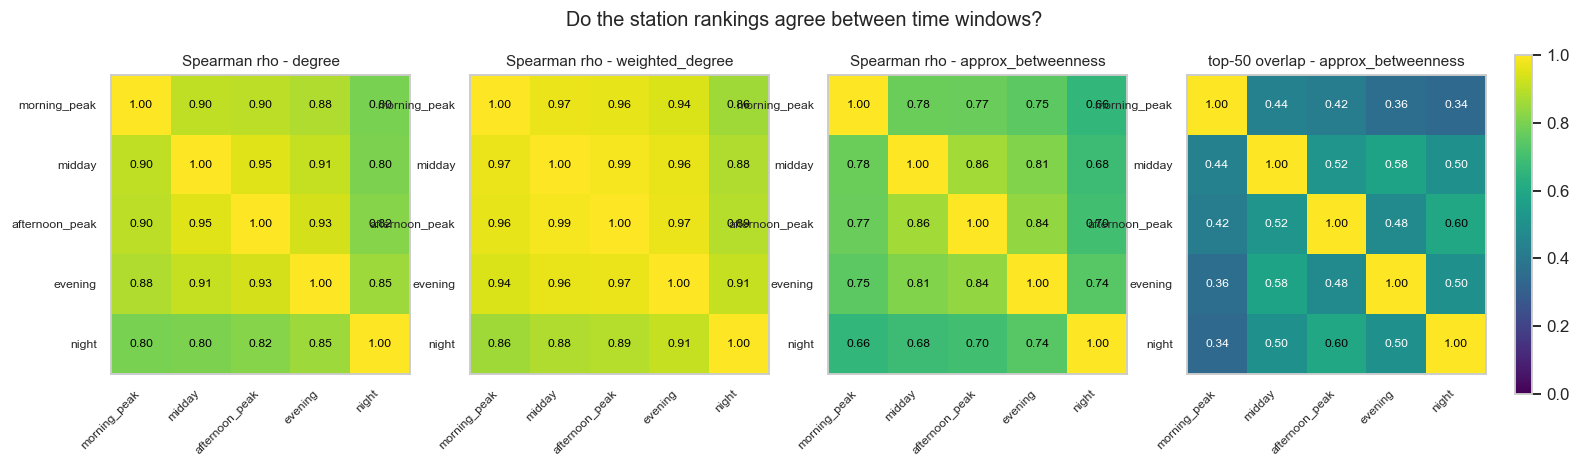

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\figures\rank_agreement_heatmap.png


In [10]:
def pair_matrix(df, metric, value_col, diag=1.0):
    M = pd.DataFrame(np.full((len(WINDOW_NAMES), len(WINDOW_NAMES)), np.nan),
                     index=WINDOW_NAMES, columns=WINDOW_NAMES, dtype=float)
    np.fill_diagonal(M.values, diag)
    sub = df[df['metric'] == metric]
    for _, r in sub.iterrows():
        M.loc[r['window_a'], r['window_b']] = r[value_col]
        M.loc[r['window_b'], r['window_a']] = r[value_col]
    return M


if len(window_agreement):
    ov_col = 'top' + str(TOP_OVERLAP_N) + '_overlap'
    panels = [(m, 'spearman_rho', 'Spearman rho - ' + m) for m in AGREEMENT_METRICS]
    panels.append((RANK_METRIC, ov_col, 'top-' + str(TOP_OVERLAP_N) + ' overlap - ' + RANK_METRIC))

    fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4.0))
    axes = np.atleast_1d(axes)
    for ax, (metric, col, title) in zip(axes, panels):
        M = pair_matrix(window_agreement, metric, col)
        im = ax.imshow(M.values, vmin=0, vmax=1, cmap='viridis')
        ax.set_xticks(range(len(WINDOW_NAMES)))
        ax.set_xticklabels(WINDOW_NAMES, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(WINDOW_NAMES)))
        ax.set_yticklabels(WINDOW_NAMES, fontsize=8)
        ax.set_title(title, fontsize=10)
        ax.grid(False)
        for i in range(len(WINDOW_NAMES)):
            for j in range(len(WINDOW_NAMES)):
                v = M.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, format(v, '.2f'), ha='center', va='center', fontsize=8,
                            color='white' if v < 0.6 else 'black')
    fig.colorbar(im, ax=list(axes), fraction=0.02, pad=0.02)
    fig.suptitle('Do the station rankings agree between time windows?', fontsize=13)
    fig.savefig(FIGURES / 'rank_agreement_heatmap.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show()
    print('saved', FIGURES / 'rank_agreement_heatmap.png')
else:
    print('skipped - needs at least two windows.')

## 10. The noise floor of the betweenness lens

Approximate betweenness changes slightly with its random pivots. We rerun it on the peak graph with `BETWEENNESS_SEED_B`, then compare the two same-graph rankings by Spearman correlation and top-set overlap. This estimates how much disagreement the estimator creates without any change in the network.

We use this as a reference level rather than a formal threshold. Cross-window agreement near the same-graph agreement may be explained by sampling alone; a noticeably larger difference is stronger evidence of a time effect. `RUN_NOISE_FLOOR = False` skips this extra calculation.

In [11]:
noise_rows = []
noise_floor = pd.DataFrame()
noise_cache_hit = False
NOISE_CACHE = TABLES / 'betweenness_noise_floor.csv'
if (RUN_NOISE_FLOOR and centrality_cache_hit and RANK_METRIC == 'approx_betweenness'
        and PEAK_WINDOW is not None and NOISE_CACHE.exists()):
    try:
        candidate = pd.read_csv(NOISE_CACHE, encoding='utf-8-sig')
        required = {'window', 'seed_a', 'seed_b', 'k_pivots'}
        if len(candidate) != 1 or not required.issubset(candidate.columns):
            raise ValueError('noise-floor cache has an invalid schema')
        row = candidate.iloc[0]
        if (str(row['window']) != str(PEAK_WINDOW)
                or int(row['seed_a']) != BETWEENNESS_SEED
                or int(row['seed_b']) != BETWEENNESS_SEED_B
                or int(row['k_pivots']) != BETWEENNESS_SAMPLES):
            raise ValueError('noise-floor parameters changed')
        noise_floor = candidate
        noise_cache_hit = True
        print('Reusing validated betweenness noise-floor cache.')
    except Exception as exc:
        print('Ignoring invalid noise-floor cache:', exc)

if (RUN_NOISE_FLOOR and not noise_cache_hit and RANK_METRIC == 'approx_betweenness'
        and PEAK_WINDOW is not None):
    print('re-running betweenness on window "' + str(PEAK_WINDOW) + '" with seed',
          BETWEENNESS_SEED_B, '...')
    alt = window_metrics(PEAK_WINDOW, GRAPHS[PEAK_WINDOW], seed=BETWEENNESS_SEED_B)
    base = metric_frames[PEAK_WINDOW]
    j = base[['stop_id', 'approx_betweenness', 'rank_approx_betweenness']].merge(
        alt[['stop_id', 'approx_betweenness', 'rank_approx_betweenness']],
        on='stop_id', suffixes=('_a', '_b'))
    ta = set(base.nsmallest(TOP_OVERLAP_N, 'rank_approx_betweenness')['stop_id'])
    tb = set(alt.nsmallest(TOP_OVERLAP_N, 'rank_approx_betweenness')['stop_id'])
    noise_rows.append({
        'window': PEAK_WINDOW, 'seed_a': BETWEENNESS_SEED, 'seed_b': BETWEENNESS_SEED_B,
        'k_pivots': BETWEENNESS_SAMPLES, 'n_stations': len(j),
        'spearman_rho_same_window': round(spearman(j['approx_betweenness_a'],
                                                   j['approx_betweenness_b']), 4),
        'top' + str(TOP_OVERLAP_N) + '_overlap_same_window':
            round(len(ta & tb) / float(TOP_OVERLAP_N), 4),
        'nonzero_share_seed_a': round(float((j['approx_betweenness_a'] > 0).mean()), 4),
    })
    noise_floor = pd.DataFrame(noise_rows)
    noise_floor.to_csv(TABLES / 'betweenness_noise_floor.csv', index=False, encoding='utf-8-sig')
    print()
    print(noise_floor.to_string(index=False))
    print()
    print('Any cross-window Spearman above',
          noise_floor.iloc[0]['spearman_rho_same_window'],
          'is within the sampling noise of the estimator and must NOT be read as "the ranking is stable in time".')
elif not noise_cache_hit:
    print('noise-floor check skipped (RUN_NOISE_FLOOR =', RUN_NOISE_FLOOR,
          ', RANK_METRIC =', RANK_METRIC, ')')

re-running betweenness on window "morning_peak" with seed 7 ...


  morning_peak       betweenness on 29,852 nodes with k=250 -> 36.5s

      window  seed_a  seed_b  k_pivots  n_stations  spearman_rho_same_window  top50_overlap_same_window  nonzero_share_seed_a
morning_peak      42       7       250       30072                    0.9597                       0.86                0.9077

Any cross-window Spearman above 0.9597 is within the sampling noise of the estimator and must NOT be read as "the ranking is stable in time".


## 11. Which stations move the most between peak and off-peak?

For the selected peak and off-peak pair, we separate two kinds of change:

* **Movers** are present in both windows but change rank. We limit this table to stations inside the top `MOVER_POOL` in at least one window because large shifts in the long low-score tail are not useful. `rank_shift = rank_offpeak - rank_peak`: positive values lose importance off-peak, while negative values gain relative importance as other service disappears.
* **Vanished stations** have peak service but do not appear in the off-peak graph. They cannot be included in a rank correlation, so we export them separately and sort them by peak-hour centrality.

Both tables include names, regions, and coordinates so we can identify the stations rather than working only with IDs.

In [12]:
movers = pd.DataFrame()
vanished = pd.DataFrame()

if OFFPEAK_WINDOW is not None:
    pk = metric_frames[PEAK_WINDOW].set_index('stop_id')
    op = metric_frames[OFFPEAK_WINDOW].set_index('stop_id')
    common = sorted(set(pk.index) & set(op.index))

    movers = pd.DataFrame({'stop_id': common})
    movers['stop_name'] = movers['stop_id'].map(pk['stop_name'])
    movers['region'] = movers['stop_id'].map(pk['region'])
    movers['lat'] = movers['stop_id'].map(pk['lat'])
    movers['lon'] = movers['stop_id'].map(pk['lon'])
    movers['metric'] = RANK_METRIC
    movers['rank_peak'] = movers['stop_id'].map(pk['rank_in_window']).astype(int)
    movers['rank_offpeak'] = movers['stop_id'].map(op['rank_in_window']).astype(int)
    movers['peak_window'] = PEAK_WINDOW
    movers['offpeak_window'] = OFFPEAK_WINDOW
    movers['degree_peak'] = movers['stop_id'].map(pk['degree']).astype(float)
    movers['degree_offpeak'] = movers['stop_id'].map(op['degree']).astype(float)
    movers['weighted_degree_peak'] = movers['stop_id'].map(pk['weighted_degree']).astype(float)
    movers['weighted_degree_offpeak'] = movers['stop_id'].map(op['weighted_degree']).astype(float)
    movers['rank_shift'] = movers['rank_offpeak'] - movers['rank_peak']
    movers['abs_rank_shift'] = movers['rank_shift'].abs()
    movers['in_pool'] = (movers[['rank_peak', 'rank_offpeak']].min(axis=1) <= MOVER_POOL)
    movers['direction'] = np.where(movers['rank_shift'] > 0, 'less central off-peak',
                          np.where(movers['rank_shift'] < 0, 'more central off-peak', 'unchanged'))
    movers = movers.sort_values('abs_rank_shift', ascending=False).reset_index(drop=True)
    movers.to_csv(TABLES / 'rank_movers.csv', index=False, encoding='utf-8-sig')

    pool = movers[movers['in_pool']]
    print('stations in both windows :', format(len(movers), ','),
          '| inside the top-' + str(MOVER_POOL), 'pool of either window:', format(len(pool), ','))
    print()
    print('--- biggest DROP off-peak (critical at rush hour only) ---')
    print(pool.nlargest(10, 'rank_shift')[
        ['stop_name', 'region', 'rank_peak', 'rank_offpeak', 'rank_shift']].to_string(index=False))
    print()
    print('--- biggest RISE off-peak (relatively more critical when service thins) ---')
    print(pool.nsmallest(10, 'rank_shift')[
        ['stop_name', 'region', 'rank_peak', 'rank_offpeak', 'rank_shift']].to_string(index=False))

    # --- stations that simply have no service in the off-peak window ---
    gone = sorted(set(pk.index) - set(op.index))
    vanished = pk.loc[gone, ['stop_name', 'region', 'lat', 'lon', 'degree',
                             'weighted_degree', 'approx_betweenness', 'rank_in_window']].copy()
    vanished = (vanished.rename(columns={'rank_in_window': 'rank_in_peak_window'})
                        .reset_index()
                        .sort_values('rank_in_peak_window'))
    vanished['peak_window'] = PEAK_WINDOW
    vanished['offpeak_window'] = OFFPEAK_WINDOW
    vanished.to_csv(TABLES / 'vanished_at_offpeak.csv', index=False, encoding='utf-8-sig')
    print()
    print('stations served in "' + str(PEAK_WINDOW) + '" but with NO service in "' +
          str(OFFPEAK_WINDOW) + '":', format(len(vanished), ','),
          '(' + str(round(100 * len(vanished) / max(len(pk), 1), 1)) + '% of the peak network)')
    if len(vanished):
        print(vanished.head(10)[['stop_name', 'region', 'rank_in_peak_window',
                                 'degree', 'weighted_degree']].to_string(index=False))
else:
    print('skipped - needs two windows.')

stations in both windows :

 25,848 | inside the top-2000 pool of either window: 3,159

--- biggest DROP off-peak (critical at rush hour only) ---
                     stop_name region  rank_peak  rank_offpeak  rank_shift
      מסוף חצור הגלילית/רציפים  North        354         25943       25589
               כפר הנוער עדנים  South        225         25678       25453
               צומת אופקים/241  South        407         25784       25377
    צומת אורים למזרח/כביש 234   South        465         25783       25318
מסוף מועצה אזורית אשכול/רציפים  South        584         25875       25291
         ת. רכבת אשקלון/רציפים Center        745         25850       25105
                גן לאומי אשכול  South        983         25782       24799
                     צומת רעים  South       1437         25915       24478
         ת.מרכזית עפולה/רציפים  North        498         24919       24421
               צומת מחנה גדעון  North       1483         25852       24369

--- biggest RISE off-peak (relatively more critical whe

### 11b. The rank movers, charted

We plot the `TOP_MOVERS` largest shifts in each direction. Bars to the right lose rank off-peak and bars to the left gain rank. We print both ranks beside each Hebrew station name so the chart shows the size as well as the direction of the change.

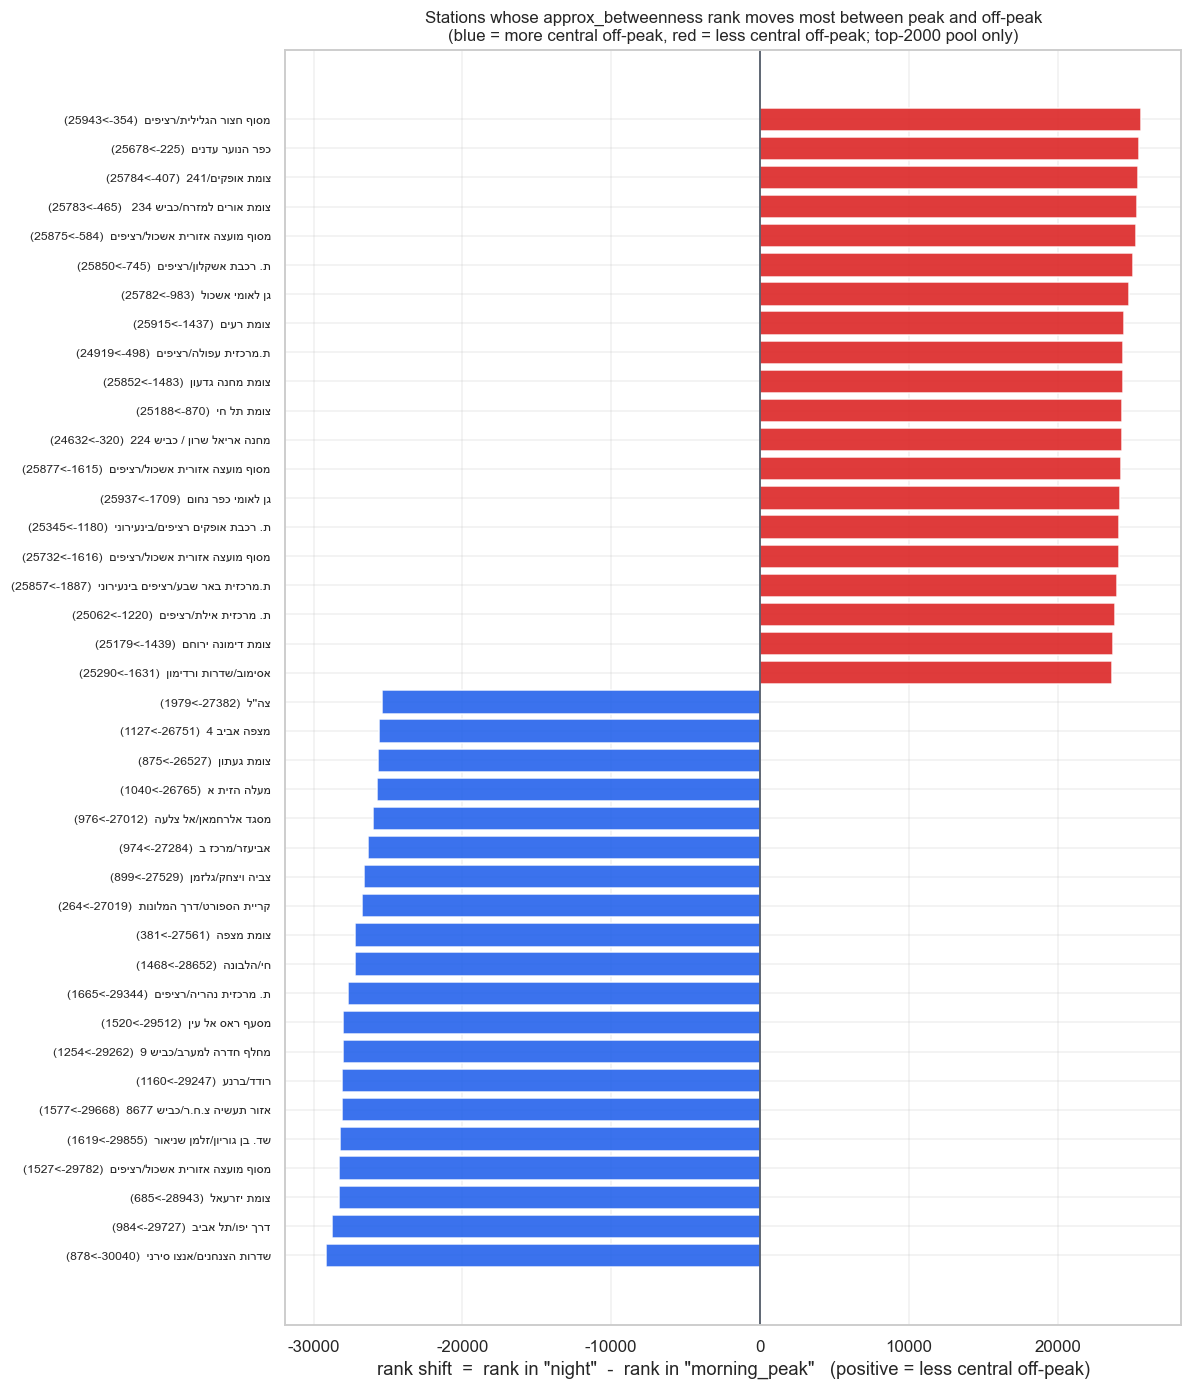

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\figures\top_rank_movers.png


In [13]:
if len(movers):
    pool = movers[movers['in_pool']]
    down = pool.nlargest(TOP_MOVERS, 'rank_shift')
    up = pool.nsmallest(TOP_MOVERS, 'rank_shift')
    sel = pd.concat([up, down]).drop_duplicates('stop_id').sort_values('rank_shift')

    labels = [(nm if isinstance(nm, str) and nm else sid) + '  (' + str(rp) + '->' + str(ro) + ')'
              for nm, sid, rp, ro in zip(sel['stop_name'], sel['stop_id'],
                                         sel['rank_peak'], sel['rank_offpeak'])]
    colors = ['#2563eb' if v < 0 else '#dc2626' for v in sel['rank_shift']]

    fig, ax = plt.subplots(figsize=(11, max(5, 0.32 * len(sel))))
    ax.barh(range(len(sel)), sel['rank_shift'], color=colors, alpha=0.9)
    ax.set_yticks(range(len(sel)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color='#374151', linewidth=1)
    ax.set_xlabel('rank shift  =  rank in "' + str(OFFPEAK_WINDOW) + '"  -  rank in "' +
                  str(PEAK_WINDOW) + '"   (positive = less central off-peak)')
    ax.set_title('Stations whose ' + RANK_METRIC + ' rank moves most between peak and off-peak\n'
                 '(blue = more central off-peak, red = less central off-peak; '
                 'top-' + str(MOVER_POOL) + ' pool only)', fontsize=11)
    fig.tight_layout()
    fig.savefig(FIGURES / 'top_rank_movers.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show()
    print('saved', FIGURES / 'top_rank_movers.png')
else:
    print('skipped - no mover table.')

## 12. The per-window attack simulation

We use the same progressive-removal structure as notebook 06 and keep two details that are necessary for a fair comparison:

* **Deduplicated attack orders** - position `k` always means that `k` distinct stations have been removed. An assertion checks this at every step.
* **Normalization by surviving nodes** - we report `|LCC| / (N_window - k)`, so the curve measures fragmentation among stations that remain. Dividing by the original node count would mix deletion with fragmentation.

Because window graphs have different sizes, we define the removal grid as a fraction of each graph, with extra small-removal anchor points. We still save the absolute number removed, but the fractional x-axis is what makes the curves comparable.

We simulate degree, weighted-degree, sampled-betweenness, and articulation-first orders, plus a random baseline averaged across seeded permutations. Each random trial uses one full permutation, so the removed sets are nested as the failure progresses.

In [14]:
def dedup_keep_order(seq):
    """Remove duplicates but keep first-occurrence order."""
    seen, out = set(), []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def k_grid_for(n):
    """Removal counts for a window of n stations, from the fraction grid."""
    fracs = sorted(set([f for f in REMOVAL_FRACTIONS] + [f for f in EXTRA_FRACTIONS]))
    ks = sorted({int(round(f * n)) for f in fracs if 0 <= f <= 1})
    return [k for k in ks if k < n]


def lcc_size(G, node_set, removed):
    """Size of the largest connected component after deleting `removed` (a set of node ids)."""
    survivors = node_set.difference(removed)
    if not survivors:
        return 0
    return max((len(c) for c in nx.connected_components(G.subgraph(survivors))), default=0)


def attack_orders(name, G, mdf):
    """The deterministic attack orders for one window, all duplicate-free."""
    m = mdf.copy()
    def by(col):
        s = m.sort_values([col, 'weighted_degree', 'degree', 'stop_id'],
                          ascending=[False, False, False, True])
        return s['stop_id'].tolist()

    aps = sorted(set(nx.articulation_points(G)))
    ap_rank = m.set_index('stop_id')['degree'].to_dict()
    aps = sorted(aps, key=lambda n: (-float(ap_rank.get(n, 0)), n))

    orders = {
        'degree': by('degree'),
        'weighted degree': by('weighted_degree'),
        'betweenness': by('approx_betweenness'),
        # articulation points first (ordered by degree), then everything else by degree
        'articulation points': dedup_keep_order(aps + by('degree')),
    }
    orders = {k: v for k, v in orders.items() if k in ATTACK_STRATEGIES}
    for k, v in orders.items():
        assert len(v) == len(set(v)), 'duplicate entries in strategy ' + k + ' / window ' + str(name)
    return orders, len(aps)


def simulate_window(name, G, mdf):
    """Run every strategy + the random baseline inside one window."""
    n0 = G.number_of_nodes()
    node_set = set(G.nodes())
    ks = k_grid_for(n0)
    orders, n_aps = attack_orders(name, G, mdf)
    rows = []

    def _row(strategy, k, size):
        surviving = n0 - k
        return {'window': name, 'strategy': strategy, 'removed': k,
                'removed_fraction': round(k / n0, 5) if n0 else 0.0,
                'window_nodes': n0, 'surviving_nodes': surviving, 'lcc_size': float(size),
                'largest_component_share_surviving': round(size / surviving, 5) if surviving > 0 else 0.0,
                'lcc_share_original': round(size / n0, 5) if n0 else 0.0}

    t0 = time.time()
    for strategy, order in orders.items():
        order = [x for x in order if x in node_set]
        for k in ks:
            removed = set(order[:k])
            assert len(removed) == k, 'strategy ' + strategy + ' removed ' + str(len(removed)) + ' != ' + str(k)
            rows.append(_row(strategy, k, lcc_size(G, node_set, removed)))

    sizes = {k: [] for k in ks}
    all_nodes = list(node_set)
    for t in range(RANDOM_TRIALS):
        rng = random.Random(SEED + t)
        perm = list(all_nodes)
        rng.shuffle(perm)
        for k in ks:
            sizes[k].append(lcc_size(G, node_set, set(perm[:k])))
    for k in ks:
        rows.append(_row('random (baseline)', k, float(np.mean(sizes[k]))))

    df = pd.DataFrame(rows)
    end = df[df['removed'] == max(ks)]
    print('  ' + str(name).ljust(18), format(n0, '>7,'), 'nodes |', len(ks), 'removal levels |',
          format(n_aps, ','), 'articulation points |', str(round(time.time() - t0, 1)) + 's')
    for _, r in end.sort_values('largest_component_share_surviving').iterrows():
        print('      at ' + str(round(100 * r['removed_fraction'], 1)) + '% removed  ' +
              str(r['strategy']).ljust(20) + ' LCC/surviving = ' +
              format(r['largest_component_share_surviving'], '.3f'))
    return df


print('running the attack simulation per window (this is the expensive cell) ...')
t_all = time.time()
sim_frames = [simulate_window(name, GRAPHS[name], metric_frames[name]) for name in WINDOW_NAMES]
resilience_detail = pd.concat(sim_frames, ignore_index=True)
print()
print('total simulation time:', round(time.time() - t_all, 1), 's |',
      format(len(resilience_detail), ','), 'rows')

running the attack simulation per window (this is the expensive cell) ...


  morning_peak        30,072 nodes | 24 removal levels | 1,119 articulation points | 11.2s
      at 10.0% removed  degree               LCC/surviving = 0.269
      at 10.0% removed  articulation points  LCC/surviving = 0.372
      at 10.0% removed  betweenness          LCC/surviving = 0.377
      at 10.0% removed  weighted degree      LCC/surviving = 0.898
      at 10.0% removed  random (baseline)    LCC/surviving = 0.937


  midday              30,195 nodes | 24 removal levels | 1,000 articulation points | 11.1s
      at 10.0% removed  degree               LCC/surviving = 0.186
      at 10.0% removed  articulation points  LCC/surviving = 0.328
      at 10.0% removed  betweenness          LCC/surviving = 0.409
      at 10.0% removed  weighted degree      LCC/surviving = 0.877
      at 10.0% removed  random (baseline)    LCC/surviving = 0.943


  afternoon_peak      30,057 nodes | 24 removal levels | 1,023 articulation points | 10.8s
      at 10.0% removed  degree               LCC/surviving = 0.180
      at 10.0% removed  articulation points  LCC/surviving = 0.384
      at 10.0% removed  betweenness          LCC/surviving = 0.427
      at 10.0% removed  weighted degree      LCC/surviving = 0.875
      at 10.0% removed  random (baseline)    LCC/surviving = 0.938


  evening             29,359 nodes | 24 removal levels | 1,179 articulation points | 10.5s
      at 10.0% removed  degree               LCC/surviving = 0.213
      at 10.0% removed  articulation points  LCC/surviving = 0.380
      at 10.0% removed  betweenness          LCC/surviving = 0.428
      at 10.0% removed  weighted degree      LCC/surviving = 0.871
      at 10.0% removed  random (baseline)    LCC/surviving = 0.931


  night               25,967 nodes | 24 removal levels | 1,795 articulation points | 8.9s
      at 10.0% removed  betweenness          LCC/surviving = 0.199
      at 10.0% removed  degree               LCC/surviving = 0.217
      at 10.0% removed  articulation points  LCC/surviving = 0.719
      at 10.0% removed  weighted degree      LCC/surviving = 0.889
      at 10.0% removed  random (baseline)    LCC/surviving = 0.896

total simulation time: 53.2 s | 600 rows


### 12b. Writing the resilience tables

We write the compact result to `dynamic_resilience.csv`: window, strategy, number removed, and survivor-normalized largest-component share. We keep the removal fraction, graph size, survivor count, raw component size, and original-node normalization in `dynamic_resilience_detail.csv` for diagnostics.

In [15]:
CONTRACT = ['window', 'strategy', 'removed', 'largest_component_share_surviving']
resilience_detail.to_csv(TABLES / 'dynamic_resilience_detail.csv', index=False, encoding='utf-8-sig')
resilience_detail[CONTRACT].to_csv(TABLES / 'dynamic_resilience.csv', index=False, encoding='utf-8-sig')
print('wrote', TABLES / 'dynamic_resilience.csv', '(' + format(len(resilience_detail), ','), 'rows )')
print(resilience_detail[CONTRACT].head(6).to_string(index=False))

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\tables\dynamic_resilience.csv (600 rows )
      window strategy  removed  largest_component_share_surviving
morning_peak   degree        0                            0.99268
morning_peak   degree       15                            0.99105
morning_peak   degree       30                            0.99055
morning_peak   degree       75                            0.98870
morning_peak   degree      150                            0.98763
morning_peak   degree      301                            0.97847


## 13. Damage curves: is the network more fragile when service is thin?

We compare damage across windows using `|LCC| / (N - k)` against the fraction of stations removed, so graph size does not determine the axis.

* **Left - degree-targeted removal.** One line per window shows whether the same removal fraction fragments a thin window faster than a busy one.
* **Right - random removal.** This is the baseline. Differences between windows here reflect their underlying topology, while the targeted-versus-random gap within one window shows the extra damage caused by choosing central stations.

A curve near 1 means most surviving stations remain together. A falling curve means the removals are splitting the surviving graph.

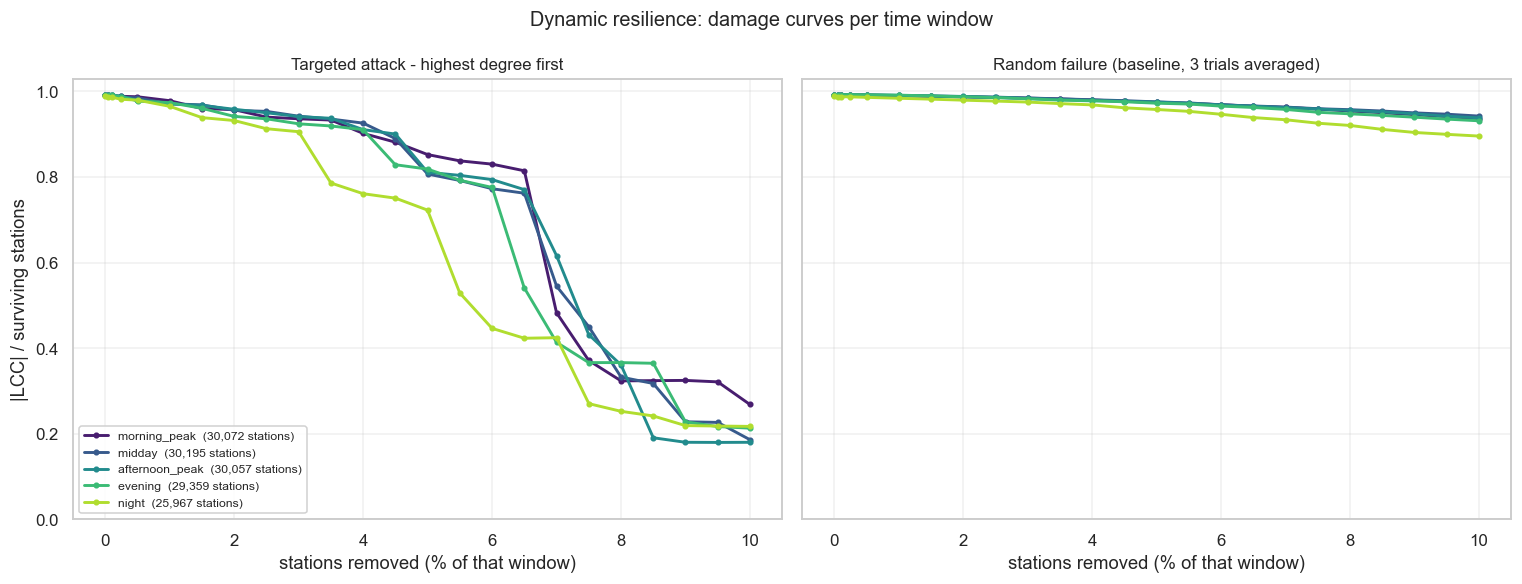

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\figures\damage_curves_by_window.png


In [16]:
WCOLORS = plt.cm.viridis(np.linspace(0.08, 0.88, max(len(WINDOW_NAMES), 1)))
WCOLOR = {w: WCOLORS[i] for i, w in enumerate(WINDOW_NAMES)}

panels = [('degree', 'Targeted attack - highest degree first'),
          ('random (baseline)', 'Random failure (baseline, ' + str(RANDOM_TRIALS) + ' trials averaged)')]
panels = [(s, t) for s, t in panels if s in set(resilience_detail['strategy'])]

fig, axes = plt.subplots(1, len(panels), figsize=(7.0 * len(panels), 5.4), sharey=True)
axes = np.atleast_1d(axes)
for ax, (strategy, title) in zip(axes, panels):
    sub = resilience_detail[resilience_detail['strategy'] == strategy]
    for w in WINDOW_NAMES:
        g = sub[sub['window'] == w].sort_values('removed_fraction')
        if g.empty:
            continue
        n0 = int(g['window_nodes'].iloc[0])
        ax.plot(100 * g['removed_fraction'], g['largest_component_share_surviving'],
                marker='o', markersize=3.0, linewidth=1.9, color=WCOLOR[w],
                label=str(w) + '  (' + format(n0, ',') + ' stations)')
    ax.set_xlabel('stations removed (% of that window)')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1.03)
axes[0].set_ylabel('|LCC| / surviving stations')
axes[0].legend(loc='lower left', fontsize=8, framealpha=0.9)
fig.suptitle('Dynamic resilience: damage curves per time window', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / 'damage_curves_by_window.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print('saved', FIGURES / 'damage_curves_by_window.png')

### 13b. Every strategy, window by window

We also plot one panel per window with every attack strategy and the random baseline. This lets us see whether degree, service volume, betweenness, or articulation status identifies the most damaging order at each time.

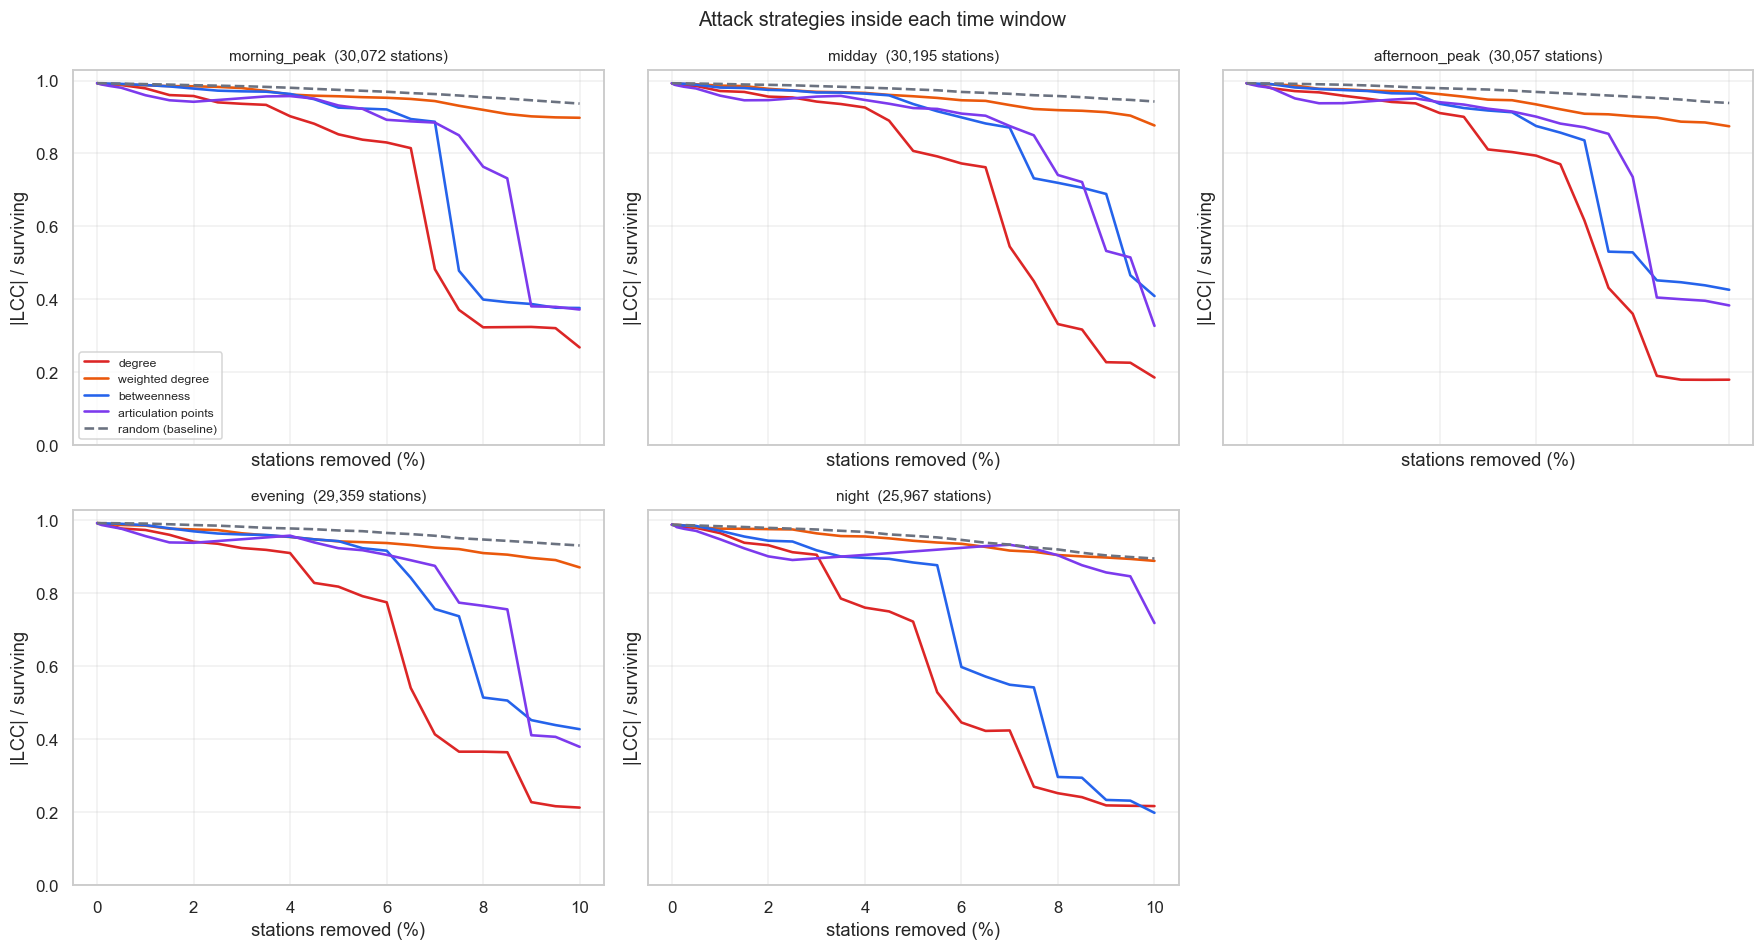

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\figures\damage_curves_grid.png


In [17]:
strats = [s for s in ATTACK_STRATEGIES if s in set(resilience_detail['strategy'])] + ['random (baseline)']
SCOLORS = {'degree': '#dc2626', 'weighted degree': '#ea580c', 'betweenness': '#2563eb',
           'articulation points': '#7c3aed', 'random (baseline)': '#6b7280'}

ncol = min(3, len(WINDOW_NAMES))
nrow = int(np.ceil(len(WINDOW_NAMES) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.4 * ncol, 4.4 * nrow), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax, w in zip(axes, WINDOW_NAMES):
    sub = resilience_detail[resilience_detail['window'] == w]
    for s in strats:
        g = sub[sub['strategy'] == s].sort_values('removed_fraction')
        if g.empty:
            continue
        ax.plot(100 * g['removed_fraction'], g['largest_component_share_surviving'],
                linewidth=1.7, color=SCOLORS.get(s, '#111827'),
                linestyle='--' if s == 'random (baseline)' else '-', label=s)
    n0 = int(sub['window_nodes'].iloc[0]) if len(sub) else 0
    ax.set_title(str(w) + '  (' + format(n0, ',') + ' stations)', fontsize=10)
    ax.set_ylim(0, 1.03)
for ax in axes[len(WINDOW_NAMES):]:
    ax.axis('off')
axes[0].legend(fontsize=8, loc='lower left')
for ax in axes[:len(WINDOW_NAMES)]:
    ax.set_xlabel('stations removed (%)')
    ax.set_ylabel('|LCC| / surviving')
fig.suptitle('Attack strategies inside each time window', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / 'damage_curves_grid.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print('saved', FIGURES / 'damage_curves_grid.png')

## 14. Scoring the curves

To summarize the full curves, we calculate these values for each window and strategy:

* **`auc`** - normalized area under the survivor-connectedness curve. Values near 1 indicate that the surviving graph stays together; lower values indicate earlier fragmentation. The fractional x-axis makes AUC comparable across windows.
* **`share_at_1pct`, `share_at_5pct`, and `share_at_10pct`** - the connected share at practical removal checkpoints, using the nearest simulated grid point.
* **`targeting_gain`** - `auc(random) - auc(strategy)`, which measures how much more damaging a targeted order is than random failure.

        window            strategy  window_nodes    auc  targeting_gain_vs_random  share_at_1pct  share_at_5pct  share_at_10pct
afternoon_peak              degree         30057 0.7122                    0.2595         0.9709         0.8112          0.1801
afternoon_peak         betweenness         30057 0.8094                    0.1623         0.9809         0.9178          0.4266
afternoon_peak articulation points         30057 0.8247                    0.1470         0.9509         0.9228          0.3837
afternoon_peak     weighted degree         30057 0.9416                    0.0301         0.9864         0.9476          0.8746
afternoon_peak   random (baseline)         30057 0.9717                    0.0000         0.9909         0.9753          0.9384
       evening              degree         29359 0.6931                    0.2755         0.9738         0.8186          0.2132
       evening         betweenness         29359 0.8231                    0.1456         0.9872        

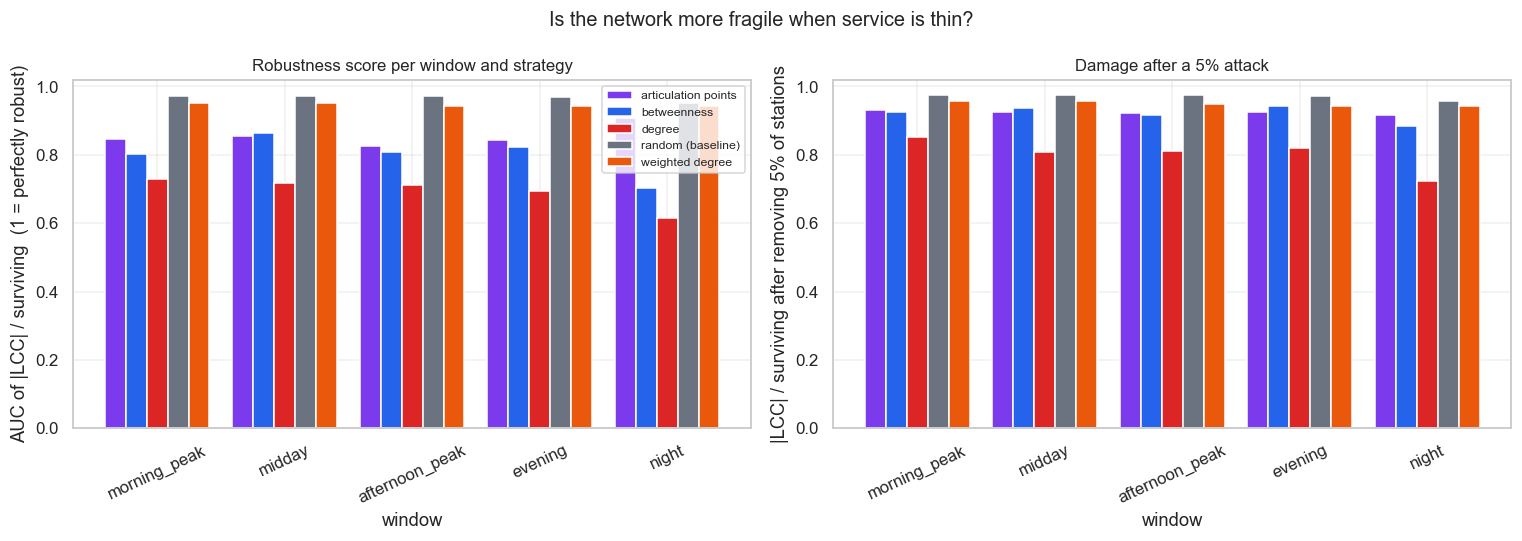

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\figures\fragility_summary.png


In [18]:
def _at(g, frac):
    if g.empty:
        return float('nan')
    i = (g['removed_fraction'] - frac).abs().idxmin()
    return float(g.loc[i, 'largest_component_share_surviving'])


rows = []
for w in WINDOW_NAMES:
    sub = resilience_detail[resilience_detail['window'] == w]
    aucs = {}
    for s in sub['strategy'].unique():
        g = sub[sub['strategy'] == s].sort_values('removed_fraction')
        x = g['removed_fraction'].to_numpy(dtype=float)
        y = g['largest_component_share_surviving'].to_numpy(dtype=float)
        span = x.max() - x.min()
        aucs[s] = float(_trapz(y, x) / span) if span > 0 else float('nan')
    base = aucs.get('random (baseline)', float('nan'))
    for s in sub['strategy'].unique():
        g = sub[sub['strategy'] == s].sort_values('removed_fraction')
        rows.append({'window': w, 'strategy': s,
                     'window_nodes': int(sub['window_nodes'].iloc[0]),
                     'auc': round(aucs[s], 4),
                     'targeting_gain_vs_random': round(base - aucs[s], 4),
                     'share_at_1pct': round(_at(g, 0.01), 4),
                     'share_at_5pct': round(_at(g, 0.05), 4),
                     'share_at_10pct': round(_at(g, 0.10), 4)})

fragility = pd.DataFrame(rows).sort_values(['window', 'auc'])
fragility.to_csv(TABLES / 'fragility_summary.csv', index=False, encoding='utf-8-sig')
print(fragility.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
piv = fragility.pivot(index='window', columns='strategy', values='auc').reindex(WINDOW_NAMES)
piv.plot(kind='bar', ax=axes[0], color=[SCOLORS.get(c, '#111827') for c in piv.columns], width=0.82)
axes[0].set_ylabel('AUC of |LCC| / surviving  (1 = perfectly robust)')
axes[0].set_title('Robustness score per window and strategy', fontsize=11)
axes[0].set_ylim(0, 1.02)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=25)

piv2 = fragility.pivot(index='window', columns='strategy',
                       values='share_at_5pct').reindex(WINDOW_NAMES)
piv2.plot(kind='bar', ax=axes[1], color=[SCOLORS.get(c, '#111827') for c in piv2.columns], width=0.82)
axes[1].set_ylabel('|LCC| / surviving after removing 5% of stations')
axes[1].set_title('Damage after a 5% attack', fontsize=11)
axes[1].set_ylim(0, 1.02)
axes[1].get_legend().remove()
axes[1].tick_params(axis='x', rotation=25)

fig.suptitle('Is the network more fragile when service is thin?', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / 'fragility_summary.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print('saved', FIGURES / 'fragility_summary.png')

## 15. Machine-readable summary

We save the window sizes, selected peak/off-peak pair, agreement range, betweenness noise baseline, fragility scores, vanished-station count, and all analysis constants in `dynamic_summary.json`. This gives us one machine-readable record of the run and the settings behind it.

In [19]:
def _f(x):
    try:
        v = float(x)
        return None if not np.isfinite(v) else round(v, 6)
    except (TypeError, ValueError):
        return None


def _json_default(o):
    """numpy scalars and Paths are not JSON-serialisable; coerce them."""
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.bool_, bool)):
        return bool(o)
    if isinstance(o, Path):
        return str(o)
    return str(o)


summary = {
    'stage': '20_dynamic_resilience',
    'source_stage': str(STAGE19.name),
    'windows': [{'window': r['window'], 'start_hour': (None if pd.isna(r['start_hour']) else r['start_hour']),
                 'end_hour': (None if pd.isna(r['end_hour']) else r['end_hour']),
                 'nodes': int(r['nodes']), 'undirected_edges': int(r['undirected_edges']),
                 'avg_degree': _f(r['avg_degree']),
                 'largest_component_share': _f(r['largest_component_share'])}
                for _, r in window_graph_summary.iterrows()],
    'peak_window': PEAK_WINDOW, 'peak_window_rule': WHY_PEAK,
    'offpeak_window': OFFPEAK_WINDOW, 'offpeak_window_rule': WHY_OFFPEAK,
    'rank_metric': RANK_METRIC,
    'cross_window_agreement': (
        {} if not len(window_agreement) else {
            m: {'spearman_min': _f(window_agreement.loc[window_agreement['metric'] == m, 'spearman_rho'].min()),
                'spearman_max': _f(window_agreement.loc[window_agreement['metric'] == m, 'spearman_rho'].max()),
                'top_overlap_min': _f(window_agreement.loc[window_agreement['metric'] == m,
                                                           'top' + str(TOP_OVERLAP_N) + '_overlap'].min()),
                'top_overlap_max': _f(window_agreement.loc[window_agreement['metric'] == m,
                                                           'top' + str(TOP_OVERLAP_N) + '_overlap'].max())}
            for m in AGREEMENT_METRICS}),
    'betweenness_noise_floor': ({} if not len(noise_floor)
                                else {k: (_f(v) if isinstance(v, (int, float, np.floating)) else v)
                                      for k, v in noise_floor.iloc[0].to_dict().items()}),
    'movers': ({} if not len(movers) else {
        'stations_in_both_windows': int(len(movers)),
        'pool_size': int(movers['in_pool'].sum()),
        'max_abs_rank_shift_in_pool': int(movers.loc[movers['in_pool'], 'abs_rank_shift'].max())
                                      if movers['in_pool'].any() else 0,
        'median_abs_rank_shift_in_pool': _f(movers.loc[movers['in_pool'], 'abs_rank_shift'].median())
                                         if movers['in_pool'].any() else None,
        'vanished_at_offpeak': int(len(vanished))}),
    'fragility': [{'window': r['window'], 'strategy': r['strategy'], 'auc': _f(r['auc']),
                   'share_at_5pct': _f(r['share_at_5pct']),
                   'targeting_gain_vs_random': _f(r['targeting_gain_vs_random'])}
                  for _, r in fragility.iterrows()],
    'constants': {'BETWEENNESS_SAMPLES': BETWEENNESS_SAMPLES, 'BETWEENNESS_SEED': BETWEENNESS_SEED,
                  'BETWEENNESS_SEED_B': BETWEENNESS_SEED_B, 'RUN_NOISE_FLOOR': RUN_NOISE_FLOOR,
                  'RANK_METRIC': RANK_METRIC, 'TOP_OVERLAP_N': TOP_OVERLAP_N,
                  'MOVER_POOL': MOVER_POOL, 'RANDOM_TRIALS': RANDOM_TRIALS, 'SEED': SEED,
                  'ATTACK_STRATEGIES': ATTACK_STRATEGIES,
                  'REMOVAL_FRACTIONS': [float(f) for f in REMOVAL_FRACTIONS],
                  'EXTRA_FRACTIONS': [float(f) for f in EXTRA_FRACTIONS]},
}

with open(STAGE / 'dynamic_summary.json', 'w', encoding='utf-8') as fh:
    json.dump(summary, fh, ensure_ascii=False, indent=2, default=_json_default)
print('wrote', STAGE / 'dynamic_summary.json')
print(json.dumps({k: summary[k] for k in ['peak_window', 'offpeak_window', 'rank_metric',
                                          'cross_window_agreement', 'betweenness_noise_floor',
                                          'movers']},
                 ensure_ascii=False, indent=2, default=_json_default)[:1800])

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\dynamic_summary.json
{
  "peak_window": "morning_peak",
  "offpeak_window": "night",
  "rank_metric": "approx_betweenness",
  "cross_window_agreement": {
    "degree": {
      "spearman_min": 0.8005,
      "spearman_max": 0.95,
      "top_overlap_min": 0.68,
      "top_overlap_max": 0.84
    },
    "weighted_degree": {
      "spearman_min": 0.8582,
      "spearman_max": 0.9864,
      "top_overlap_min": 0.38,
      "top_overlap_max": 0.82
    },
    "approx_betweenness": {
      "spearman_min": 0.6604,
      "spearman_max": 0.8605,
      "top_overlap_min": 0.34,
      "top_overlap_max": 0.6
    }
  },
  "betweenness_noise_floor": {
    "window": "morning_peak",
    "seed_a": 42.0,
    "seed_b": 7.0,
    "k_pivots": 250.0,
    "n_stations": 30072.0,
    "spearman_rho_same_window": 0.9597,
    "top50_overlap_same_window": 0.86,
    "nonzero_share_seed_a": 0.9077
  },
  "movers": {
  

## 16. What this stage produced

We finish by listing every generated file and checking the columns of the two main output tables. This is a quick way to catch an incomplete run before we use the results elsewhere.

In [20]:
print('files under', STAGE, ':')
for p in sorted(STAGE.rglob('*')):
    if p.is_file():
        print('  ' + str(p.relative_to(STAGE)).ljust(46), format(p.stat().st_size, '>10,'), 'bytes')

print()
for fname, cols in [('dynamic_resilience.csv', CONTRACT),
                    ('peak_vs_offpeak_centrality.csv', CONTRACT_COLS)]:
    got = list(pd.read_csv(TABLES / fname, nrows=1, encoding='utf-8-sig').columns)
    print(fname, '->', 'OK' if got == cols else 'MISMATCH', '|', got)

files under C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience :
  dynamic_summary.json                                7,633 bytes
  figures\damage_curves_by_window.png               144,840 bytes
  figures\damage_curves_grid.png                    260,585 bytes
  figures\fragility_summary.png                      93,902 bytes
  figures\rank_agreement_heatmap.png                134,903 bytes
  figures\top_rank_movers.png                       216,795 bytes
  tables\betweenness_noise_floor.csv                    165 bytes
  tables\dynamic_resilience.csv                      22,658 bytes
  tables\dynamic_resilience_detail.csv               44,608 bytes
  tables\fragility_summary.csv                        1,741 bytes
  tables\peak_vs_offpeak_centrality.csv          12,078,006 bytes
  tables\rank_movers.csv                          4,413,855 bytes
  tables\vanished_at_offpeak.csv                    480,971 bytes
  tables\window_centrality_

## 17. Conclusions

The exact values depend on our window definitions and betweenness seeds, so we keep those settings beside the results in `dynamic_summary.json`. The results are more mixed than a simple claim that the same stations stay important all day:

1. **Broad rank agreement stays fairly high, but the top lists move.** Between morning peak and night, Spearman agreement is 0.801 for degree, 0.858 for weighted degree, and 0.660 for sampled betweenness. The corresponding top-50 overlaps are only 0.68, 0.38, and 0.34. A strong whole-network correlation therefore does not mean that the exact intervention shortlist is stable.

2. **Some stations disappear from the graph completely.** There are 4,224 morning-peak stations with no active night edge, equal to 14.0% of the morning graph. We keep them in `vanished_at_offpeak.csv` instead of assigning them an artificial night rank.

3. **The cross-window betweenness change is larger than the sampling noise we measured.** Repeating morning-peak betweenness with a different seed gives Spearman 0.960 and top-50 overlap 0.86. Morning-versus-night drops to 0.660 and 0.34, so the observed time difference is not explained by that seed check alone.

4. **Targeted damage changes by window and by ranking.** After removing 10% of stations, the surviving-component share under degree targeting ranges from 0.180 in the afternoon to 0.269 in the morning; night is 0.217. Betweenness targeting leaves 0.377-0.428 in the four earlier windows but only 0.199 at night. Random removal is much less damaging, leaving 0.896-0.943, while weighted-degree removal leaves 0.871-0.898.

5. **Night has the largest degree-targeting gain over random failure.** Its degree AUC is 0.614 compared with a targeting gain of 0.337; morning degree AUC is 0.730 with a gain of 0.242. This tells us that thinner service changes not only graph size but also how strongly a central-station attack separates from the random baseline.

Our conclusion is that a full-day graph is useful for finding recurring structural corridors, but it is not enough for a time-specific priority list. The model still ignores walking, waiting, transfers, and passenger demand, and its betweenness is sampled on hop distance. We therefore treat these curves as scheduled-topology stress tests rather than operational disruption forecasts.